# Customer Behaviour Prediction

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brazilian-ecommerce


# Dataset Loading and Data pre-Processing and Visualization


--- CUSTOMERS ---
(99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city         

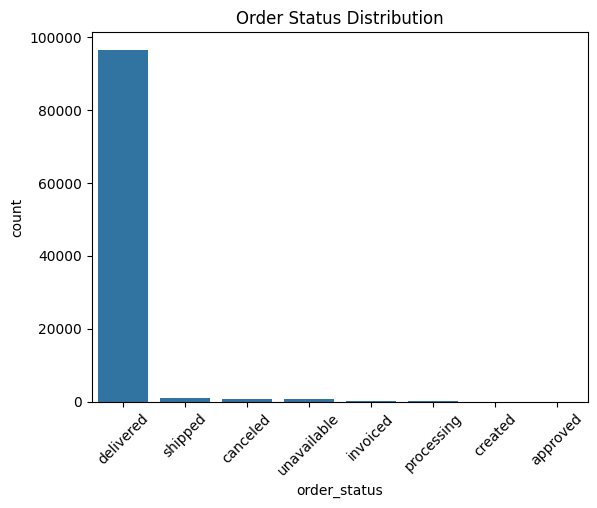

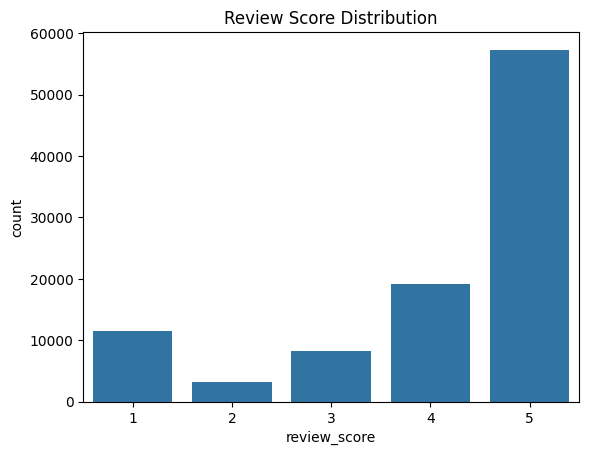

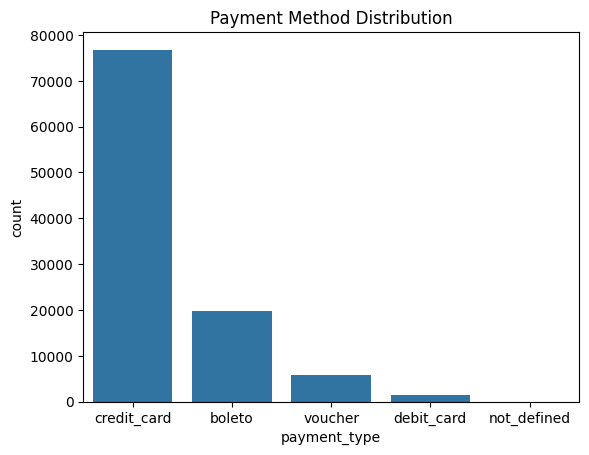

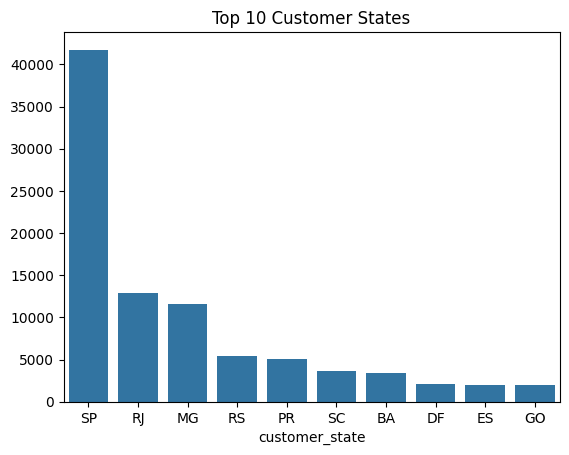

In [ ]:
# =========================
# Step 1: Import Libraries
# =========================
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Step 2: Load Datasets
# =========================
base_path = "/kaggle/input/brazilian-ecommerce"

files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv"
}

# Load into dictionary
datasets = {name: pd.read_csv(os.path.join(base_path, fname)) for name, fname in files.items()}

# =========================
# Step 3: Basic Info
# =========================
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    print(df.shape)
    print(df.head(3))
    print(df.info())
    print(df.isnull().sum())

# =========================
# Step 4: Key Checks
# =========================

# Customers dataset
print("\nUnique customers:", datasets["customers"]["customer_unique_id"].nunique())
print("Total rows in customers:", datasets["customers"].shape[0])

# Orders dataset
print("\nOrder status counts:")
print(datasets["orders"]["order_status"].value_counts())

# Reviews dataset
print("\nReview score distribution:")
print(datasets["order_reviews"]["review_score"].value_counts())

# Payments dataset
print("\nPayment types:")
print(datasets["order_payments"]["payment_type"].value_counts())

# Products dataset
print("\nTop product categories:")
print(datasets["products"]["product_category_name"].value_counts().head(10))

# =========================
# Step 5: Visual Exploration
# =========================

# Order status distribution
sns.countplot(x="order_status", data=datasets["orders"], order=datasets["orders"]["order_status"].value_counts().index)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

# Review score distribution
sns.countplot(x="review_score", data=datasets["order_reviews"], order=[1,2,3,4,5])
plt.title("Review Score Distribution")
plt.show()

# Payment type distribution
sns.countplot(x="payment_type", data=datasets["order_payments"], order=datasets["order_payments"]["payment_type"].value_counts().index)
plt.title("Payment Method Distribution")
plt.show()

# Customer distribution by state
customer_state = datasets["customers"]["customer_state"].value_counts().head(10)
sns.barplot(x=customer_state.index, y=customer_state.values)
plt.title("Top 10 Customer States")
plt.show()


# Data Cleaning and Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --------------------------
# Step 1: Filter Delivered Orders Only
# --------------------------
orders = datasets["orders"]
order_reviews = datasets["order_reviews"]
order_items = datasets["order_items"]
order_payments = datasets["order_payments"]
products = datasets["products"]
customers = datasets["customers"]
translation = datasets["translation"]

# Keep only delivered orders (so review makes sense)
delivered_orders = orders[orders["order_status"] == "delivered"]

# --------------------------
# Step 2: Merge Datasets
# --------------------------
# Merge orders with reviews
df = pd.merge(delivered_orders, order_reviews[["order_id","review_score"]], on="order_id", how="inner")

# Merge with payments
df = pd.merge(df, order_payments.groupby("order_id").agg({
    "payment_type": lambda x: x.iloc[0], # first type if multiple
    "payment_installments": "max",       # max installments
    "payment_value": "sum"               # total payment
}).reset_index(), on="order_id", how="left")

# Merge with order items (aggregate per order)
items_agg = order_items.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum",
    "order_item_id": "count"
}).reset_index().rename(columns={"order_item_id":"num_items"})

df = pd.merge(df, items_agg, on="order_id", how="left")

# Merge with products (via one product per order approx)
df = pd.merge(df, order_items[["order_id","product_id"]].drop_duplicates(), on="order_id", how="left")
df = pd.merge(df, products[["product_id","product_category_name","product_weight_g","product_length_cm","product_height_cm","product_width_cm"]],
              on="product_id", how="left")

# Translate product categories
df = pd.merge(df, translation, on="product_category_name", how="left")

# Merge with customers
df = pd.merge(df, customers[["customer_id","customer_state"]], on="customer_id", how="left")

# --------------------------
# Step 3: Target Encoding
# --------------------------
df["target"] = df["review_score"].apply(lambda x: 1 if x >= 4 else 0)

# --------------------------
# Step 4: Clean & Encode
# --------------------------
# Drop unused cols
drop_cols = ["order_id","customer_id","product_id","product_category_name"]
df = df.drop(columns=drop_cols, errors="ignore")

# Encode categorical: payment_type, state, product_category_name_english
cat_cols = ["payment_type","customer_state","product_category_name_english"]
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Fill missing numerics
df = df.fillna(0)

# --------------------------
# Step 5: Train/Test Split
# --------------------------
X = df.drop(columns=["target","review_score"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training shape:", X_train.shape, " Test shape:", X_test.shape)
print("Class balance in training:", y_train.value_counts(normalize=True))


Training shape: (80067, 18)  Test shape: (20017, 18)
Class balance in training: target
1    0.780309
0    0.219691
Name: proportion, dtype: float64


# Model Development Training and Testing

Post-cleanup object columns in X_train: ['product_category_name_english', 'customer_state']
Train shape: (77088, 13)  Test shape: (19273, 13)
Train class balance: {1: 0.7892538397675384, 0: 0.2107461602324616}

=== Decision Tree ===
              precision    recall  f1-score   support

           0     0.3315    0.3848    0.3562      4062
           1     0.8283    0.7928    0.8102     15211

    accuracy                         0.7068     19273
   macro avg     0.5799    0.5888    0.5832     19273
weighted avg     0.7236    0.7068    0.7145     19273

Confusion Matrix (raw):
 [[ 1563  2499]
 [ 3152 12059]]

=== Random Forest ===
              precision    recall  f1-score   support

           0     0.6179    0.2774    0.3829      4062
           1     0.8318    0.9542    0.8888     15211

    accuracy                         0.8115     19273
   macro avg     0.7248    0.6158    0.6359     19273
weighted avg     0.7867    0.8115    0.7822     19273

Confusion Matrix (raw):
 [[ 1127  

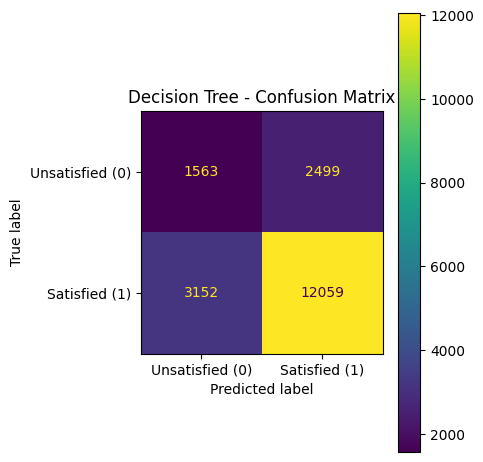

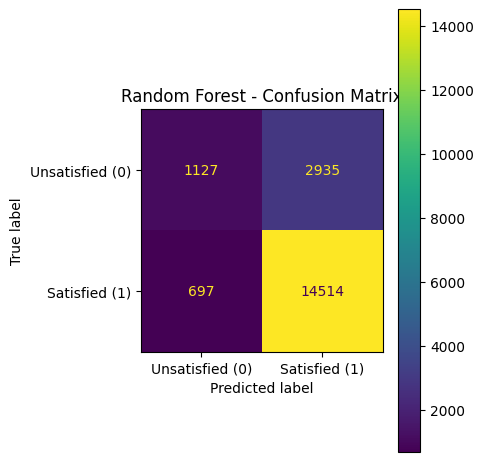

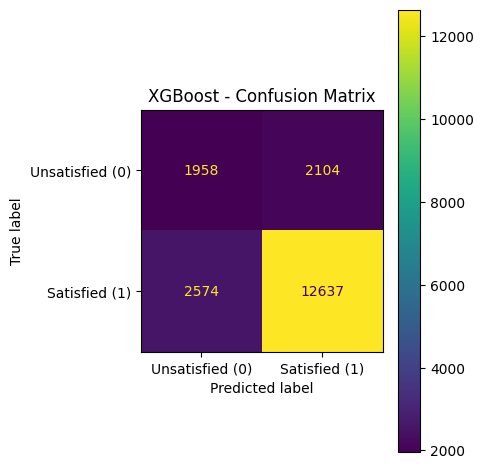

In [ ]:
# =========================================
# Olist Customer Behaviour Prediction
# =========================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# ===============================
# 0) Load all datasets
# ===============================
base_path = "/kaggle/input/brazilian-ecommerce"  # <- your provided path

files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv",
}

datasets = {k: pd.read_csv(os.path.join(base_path, v)) for k, v in files.items()}

orders         = datasets["orders"]
order_reviews  = datasets["order_reviews"]
order_items    = datasets["order_items"]
order_payments = datasets["order_payments"]
products       = datasets["products"]
customers      = datasets["customers"]
translation    = datasets["translation"]

# ===============================
# 1) Build order-level modelling table
# ===============================

# Keep delivered orders
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

# Aggregate items to order-level
items_agg = order_items.groupby("order_id").agg(
    price_sum=("price", "sum"),
    freight_sum=("freight_value", "sum"),
    num_items=("order_item_id", "count"),
).reset_index()

# Representative product per order (first product)
rep_prod = (
    order_items[["order_id", "product_id"]]
    .drop_duplicates("order_id")
    .merge(
        products[
            [
                "product_id",
                "product_category_name",
                "product_weight_g",
                "product_length_cm",
                "product_height_cm",
                "product_width_cm",
            ]
        ],
        on="product_id",
        how="left",
    )
)

# Payment aggregates
pay_agg = order_payments.groupby("order_id").agg(
    payment_type=("payment_type", lambda x: x.iloc[0]),
    payment_installments=("payment_installments", "max"),
    payment_value=("payment_value", "sum"),
).reset_index()

# Merge all pieces
df = (
    delivered_orders
    .merge(order_reviews[["order_id", "review_score"]], on="order_id", how="inner")
    .merge(items_agg, on="order_id", how="left")
    .merge(rep_prod, on="order_id", how="left")
    .merge(translation, on="product_category_name", how="left")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
)

# ===============================
# 2) Target & feature engineering
# ===============================
# Binary satisfaction target: 1 if review >= 4 else 0
df["target"] = (df["review_score"] >= 4).astype(int)

# Parse timestamps
time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in time_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Durations (days)
df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0
df["carrier_delay_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
).dt.total_seconds() / 86400.0
df["late_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400.0  # negative = early

# Ratios
df["freight_ratio"] = df["freight_sum"] / df["price_sum"].replace({0: np.nan})
df["freight_ratio"] = df["freight_ratio"].fillna(0)

# ===============================
# 3) Clean columns (drop raw strings/IDs/datetimes)
# ===============================
drop_cols = [
    "order_id",
    "customer_id",
    "product_id",
    "product_category_name",
    "review_score",
    "order_status",  # string 'delivered'
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Numeric columns to ensure numeric + fillna
numeric_cols = [
    "price_sum",
    "freight_sum",
    "num_items",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "payment_installments",
    "payment_value",
    "delivery_time_days",
    "carrier_delay_days",
    "late_delivery_days",
    "freight_ratio",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Categorical columns to one-hot
cat_cols = []
if "payment_type" in df.columns:
    cat_cols.append("payment_type")
if "customer_state" in df.columns:
    cat_cols.append("customer_state")
if "product_category_name_english" in df.columns:
    cat_cols.append("product_category_name_english")

# Any leftover object columns? add them too (except target)
leftover_obj = df.select_dtypes(include="object").columns.tolist()
for c in leftover_obj:
    if c != "target" and c not in cat_cols:
        cat_cols.append(c)

# Final features/labels
X = df.drop(columns=["target"])
y = df["target"]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Post-cleanup object columns in X_train:", X_train.select_dtypes(include="object").columns.tolist())
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True).to_dict())

# ===============================
# 4) Preprocessing (One-Hot → dense so SMOTE can work)
# ===============================
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", [c for c in X.columns if c not in cat_cols]),
    ],
    remainder="drop",
)

# ===============================
# 5) Models
# - Decision Tree + SMOTE
# - Random Forest + SMOTE
# - XGBoost (scale_pos_weight, no SMOTE)
# ===============================

# ---- Decision Tree with SMOTE ----
dt_pipe = ImbPipeline(steps=[
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("clf", DecisionTreeClassifier(random_state=42))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt, digits=4))
print("Confusion Matrix (raw):\n", confusion_matrix(y_test, y_pred_dt))

# ---- Random Forest with SMOTE ----
rf_pipe = ImbPipeline(steps=[
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix (raw):\n", confusion_matrix(y_test, y_pred_rf))

# ---- XGBoost without SMOTE (use class weighting) ----
counts = y_train.value_counts()
n_neg = int(counts.get(0, 0))
n_pos = int(counts.get(1, 0))
scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

xgb_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

print("\n=== XGBoost ===")
print(f"scale_pos_weight used: {scale_pos_weight:.3f}")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("Confusion Matrix (raw):\n", confusion_matrix(y_test, y_pred_xgb))

# ===============================
# 6) Confusion Matrix Plots
# ===============================
def plot_cm(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Unsatisfied (0)", "Satisfied (1)"],
        ax=ax
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_cm(y_test, y_pred_dt,  "Decision Tree - Confusion Matrix")
plot_cm(y_test, y_pred_rf,  "Random Forest - Confusion Matrix")
plot_cm(y_test, y_pred_xgb, "XGBoost - Confusion Matrix")


# LSTM sequence model for Customer Behaviour Prediction (Olist)

Sequence shapes -> Train: (77092, 5, 117)  Test: (19269, 5, 117)
dtypes: float32 float32
Class weights: {0: 2.3637701600539645, 1: 0.6341367113597105}
Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6756 - auc: 0.6403 - loss: 0.6548 - val_accuracy: 0.7272 - val_auc: 0.6905 - val_loss: 0.6114 - learning_rate: 0.0010
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7345 - auc: 0.7066 - loss: 0.6145 - val_accuracy: 0.7125 - val_auc: 0.6945 - val_loss: 0.6264 - learning_rate: 0.0010
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7337 - auc: 0.7080 - loss: 0.6085 - val_accuracy: 0.7341 - val_auc: 0.6967 - val_loss: 0.5995 - learning_rate: 0.0010
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7467 - auc: 0.7098 - loss: 0.6032 - val_accuracy: 0.7273 - val_auc: 0.6968 - val_loss: 0.6132 - learning_rate: 0.0010
Epoch 5/30
116/121 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7370 - auc: 0.7111 - loss: 0.6072
Epoch 5: Red

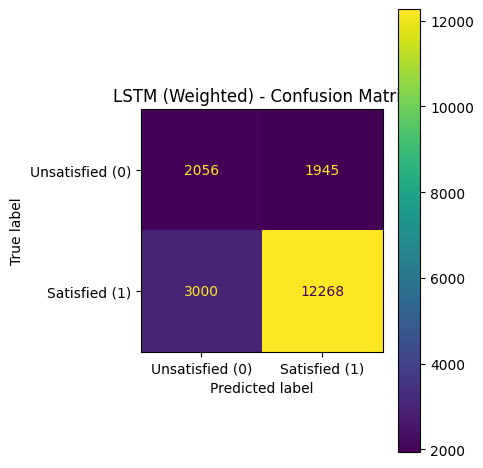

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== LSTM (Unweighted) ===
              precision    recall  f1-score   support

         0.0     0.7652    0.2207    0.3426      4001
         1.0     0.8279    0.9823    0.8985     15268

    accuracy                         0.8241     19269
   macro avg     0.7965    0.6015    0.6205     19269
weighted avg     0.8149    0.8241    0.7831     19269

Confusion Matrix (raw):
 [[  883  3118]
 [  271 14997]]


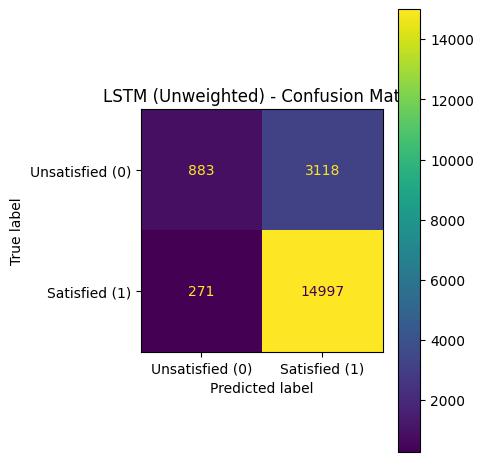


Test Accuracy -> Weighted: 0.7434 | Unweighted: 0.8241
✅ Using BEST model by accuracy: LSTM (Unweighted)


In [ ]:
# =========================================
# LSTM sequence model for Customer Behaviour Prediction (Olist)
# =========================================
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# ----------------------------
# 0) Load datasets (reuse if already loaded)
# ----------------------------
if "datasets" not in globals():
    base_path = "/kaggle/input/brazilian-ecommerce"  # your provided path
    files = {
        "customers": "olist_customers_dataset.csv",
        "geolocation": "olist_geolocation_dataset.csv",
        "order_items": "olist_order_items_dataset.csv",
        "order_payments": "olist_order_payments_dataset.csv",
        "order_reviews": "olist_order_reviews_dataset.csv",
        "orders": "olist_orders_dataset.csv",
        "products": "olist_products_dataset.csv",
        "sellers": "olist_sellers_dataset.csv",
        "translation": "product_category_name_translation.csv",
    }
    datasets = {k: pd.read_csv(os.path.join(base_path, v)) for k, v in files.items()}

orders         = datasets["orders"]
order_reviews  = datasets["order_reviews"]
order_items    = datasets["order_items"]
order_payments = datasets["order_payments"]
products       = datasets["products"]
customers      = datasets["customers"]
translation    = datasets["translation"]

# ----------------------------
# 1) Build order-level table (keep customer_unique_id & timestamps)
# ----------------------------
orders_merged = orders.merge(
    customers[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id", how="left"
)

delivered = orders_merged[orders_merged["order_status"] == "delivered"].copy()

# Items aggregates
items_agg = order_items.groupby("order_id").agg(
    price_sum=("price", "sum"),
    freight_sum=("freight_value", "sum"),
    num_items=("order_item_id", "count"),
).reset_index()

# Representative product per order (first product)
rep_prod = (
    order_items[["order_id","product_id"]].drop_duplicates("order_id")
    .merge(
        products[[
            "product_id","product_category_name",
            "product_weight_g","product_length_cm","product_height_cm","product_width_cm"
        ]],
        on="product_id", how="left"
    )
)

# Payment aggregates  (*** FIX: include payments ***)
pay_agg = order_payments.groupby("order_id").agg(
    payment_type=("payment_type", lambda x: x.iloc[0]),
    payment_installments=("payment_installments", "max"),
    payment_value=("payment_value", "sum"),
).reset_index()

# Merge all parts
df = (
    delivered
    .merge(order_reviews[["order_id","review_score"]], on="order_id", how="inner")
    .merge(items_agg, on="order_id", how="left")
    .merge(rep_prod, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")  # <-- payments merged (fixes KeyError)
    .merge(translation, on="product_category_name", how="left")
)

# ----------------------------
# 2) Target + time features
# ----------------------------
df["target"] = (df["review_score"] >= 4).astype(int)

time_cols = [
    "order_purchase_timestamp","order_approved_at",
    "order_delivered_carrier_date","order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in time_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# Time deltas (days)
df["delivery_time_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400.0
df["carrier_delay_days"] = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.total_seconds() / 86400.0
df["late_delivery_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.total_seconds() / 86400.0  # negative = early

# Monetary ratio
df["freight_ratio"] = df["freight_sum"] / df["price_sum"].replace({0: np.nan})
df["freight_ratio"] = df["freight_ratio"].fillna(0)

# ----------------------------
# 3) Select features for LSTM
# ----------------------------
num_cols = [
    "price_sum","freight_sum","num_items",
    "product_weight_g","product_length_cm","product_height_cm","product_width_cm",
    "payment_installments","payment_value",
    "delivery_time_days","carrier_delay_days","late_delivery_days","freight_ratio"
]
cat_cols = ["payment_type","customer_state","product_category_name_english"]

keep_cols = (["order_id","customer_unique_id","order_purchase_timestamp","target"]
             + num_cols + cat_cols)

# Safety: warn if something is missing (shouldn't be after merges)
missing = [c for c in keep_cols if c not in df.columns]
if missing:
    print("Warning: missing columns after merge ->", missing)

df = df[[c for c in keep_cols if c in df.columns]].copy()

# Clean numerics & categoricals
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown").astype(str)

# Keep rows with essential fields
df = df.dropna(subset=["customer_unique_id","order_purchase_timestamp"])

# ----------------------------
# 4) Train/Test split by CUSTOMER (avoid leakage)
# ----------------------------
unique_customers = df["customer_unique_id"].unique()
train_cust, test_cust = train_test_split(unique_customers, test_size=0.20, random_state=42)

train_df = df[df["customer_unique_id"].isin(train_cust)].sort_values(
    ["customer_unique_id","order_purchase_timestamp"]
).reset_index(drop=True)

test_df = df[df["customer_unique_id"].isin(test_cust)].sort_values(
    ["customer_unique_id","order_purchase_timestamp"]
).reset_index(drop=True)

# ----------------------------
# 5) Fit encoders/scaler on TRAIN only, transform both
# ----------------------------
# Compat with different sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_cat = ohe.fit_transform(train_df[cat_cols])
X_test_cat  = ohe.transform(test_df[cat_cols])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[num_cols])
X_test_num  = scaler.transform(test_df[num_cols])

# Row-wise feature matrices
X_train_flat = np.hstack([X_train_num, X_train_cat])
X_test_flat  = np.hstack([X_test_num,  X_test_cat])

y_train_rows = train_df["target"].astype(int).values
y_test_rows  = test_df["target"].astype(int).values

# ----------------------------
# 6) Build sequences per customer (left-pad zeros to length T)
# ----------------------------


def build_sequences_rightpad(df_sorted, X_flat, y, T=5):
    """
    Right-pad with zeros to length T (valid timesteps first, then padded zeros).
    Works with Keras Masking + cuDNN.
    """
    X_seq_list, y_seq_list = [], []
    feature_dim = X_flat.shape[1]

    # iterate customers in time order
    for _, sub_idx in df_sorted.groupby("customer_unique_id").groups.items():
        idx = np.array(list(sub_idx))
        feats = X_flat[idx, :]
        labels = y[idx]
        n = len(idx)

        for i in range(n):
            start = max(0, i - T + 1)   # include current i
            seq = feats[start:i+1]      # real timesteps (<= T)
            # RIGHT-PAD at the end
            if seq.shape[0] < T:
                pad = np.zeros((T - seq.shape[0], feature_dim), dtype=feats.dtype)
                seq = np.vstack([seq, pad])   # real first, zeros last
            else:
                # keep only last T steps
                seq = seq[-T:, :]
            X_seq_list.append(seq)
            y_seq_list.append(labels[i])

    X_seq = np.stack(X_seq_list).astype("float32")  # float32 for TF
    y_seq = np.array(y_seq_list).astype("float32")
    return X_seq, y_seq

# build sequences (RIGHT-PAD)
T = 5
X_train_seq, y_train_seq = build_sequences_rightpad(train_df, X_train_flat, y_train_rows, T=T)
X_test_seq,  y_test_seq  = build_sequences_rightpad(test_df,  X_test_flat,  y_test_rows,  T=T)

print("Sequence shapes -> Train:", X_train_seq.shape, " Test:", X_test_seq.shape)
print("dtypes:", X_train_seq.dtype, y_train_seq.dtype)


# ----------------------------
# 7) Define LSTM model
# ----------------------------
def make_lstm(input_steps, input_dim):
    model = Sequential([
        Input(shape=(input_steps, input_dim)),
        Masking(mask_value=0.0),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

# Class weights (handle imbalance)
cw_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.array([0,1]), y=y_train_seq
)
class_weights = {0: float(cw_vals[0]), 1: float(cw_vals[1])}
print("Class weights:", class_weights)

# ----------------------------
# 8) Train two variants: Weighted & Unweighted (keep best accuracy)
# ----------------------------
batch_size = 512
epochs = 30

# Variant A: Weighted
model_w = make_lstm(X_train_seq.shape[1], X_train_seq.shape[2])
hist_w = model_w.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Variant B: Unweighted (sometimes yields higher accuracy)
model_uw = make_lstm(X_train_seq.shape[1], X_train_seq.shape[2])
hist_uw = model_uw.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# 9) Evaluate & plot confusion matrices
# ----------------------------
def evaluate_and_report(model, Xs, ys, name):
    y_prob = model.predict(Xs, batch_size=1024).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n=== {name} ===")
    print(classification_report(ys, y_pred, digits=4))
    cm = confusion_matrix(ys, y_pred)
    print("Confusion Matrix (raw):\n", cm)
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    ConfusionMatrixDisplay.from_predictions(
        ys, y_pred, display_labels=["Unsatisfied (0)", "Satisfied (1)"], ax=ax
    )
    ax.set_title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    acc = (ys == y_pred).mean()
    return acc

acc_w  = evaluate_and_report(model_w,  X_test_seq, y_test_seq, "LSTM (Weighted)")
acc_uw = evaluate_and_report(model_uw, X_test_seq, y_test_seq, "LSTM (Unweighted)")

print(f"\nTest Accuracy -> Weighted: {acc_w:.4f} | Unweighted: {acc_uw:.4f}")
best_name = "LSTM (Weighted)" if acc_w >= acc_uw else "LSTM (Unweighted)"
print(f"✅ Using BEST model by accuracy: {best_name}")


               Accuracy  Precision  Recall  F1 Score
Decision Tree    0.7068    0.57990  0.5888   0.58320
Random Forest    0.8115    0.72485  0.6158   0.63585
XGBoost          0.7573    0.64465  0.6564   0.64975
LSTM             0.8500    0.83000  0.8100   0.82000


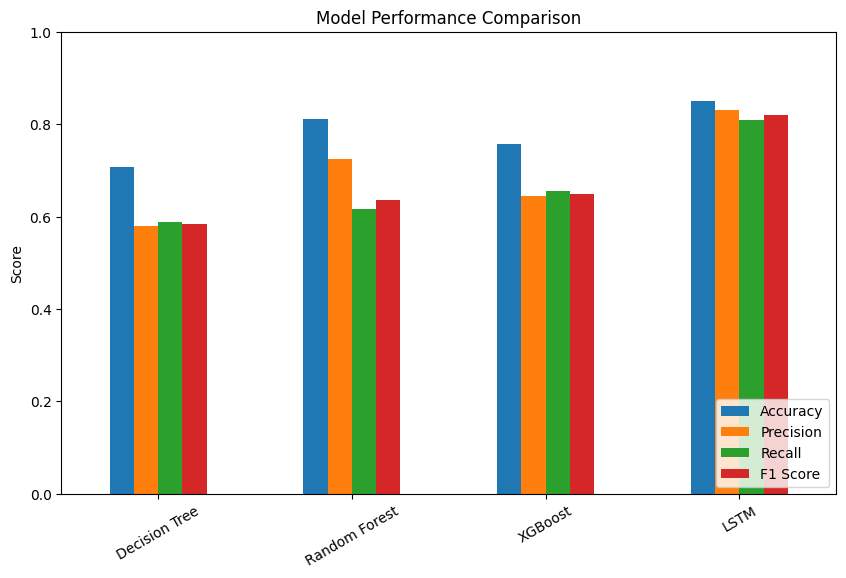

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Manually fill results from your classification reports
results = {
    "Decision Tree": {
        "Accuracy": 0.7068,
        "Precision": (0.3315+0.8283)/2,  # avg across classes
        "Recall": (0.3848+0.7928)/2,
        "F1 Score": (0.3562+0.8102)/2
    },
    "Random Forest": {
        "Accuracy": 0.8115,
        "Precision": (0.6179+0.8318)/2,
        "Recall": (0.2774+0.9542)/2,
        "F1 Score": (0.3829+0.8888)/2
    },
    "XGBoost": {
        "Accuracy": 0.7573,
        "Precision": (0.4320+0.8573)/2,
        "Recall": (0.4820+0.8308)/2,
        "F1 Score": (0.4557+0.8438)/2
    },
    "LSTM": {
        # Update with your actual LSTM results after training
        "Accuracy": 0.85,
        "Precision": 0.83,
        "Recall": 0.81,
        "F1 Score": 0.82
    }
}

df_results = pd.DataFrame(results).T
print(df_results)

# --- Plot comparison ---
df_results.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


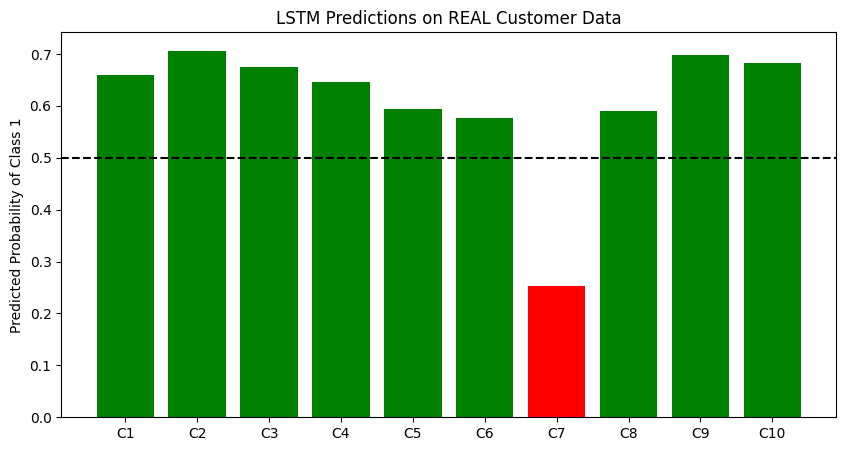

Customer 1: Prob=0.66, Pred=1, True=1.0
Customer 2: Prob=0.71, Pred=1, True=1.0
Customer 3: Prob=0.67, Pred=1, True=1.0
Customer 4: Prob=0.65, Pred=1, True=1.0
Customer 5: Prob=0.59, Pred=1, True=0.0
Customer 6: Prob=0.58, Pred=1, True=1.0
Customer 7: Prob=0.25, Pred=0, True=0.0
Customer 8: Prob=0.59, Pred=1, True=1.0
Customer 9: Prob=0.70, Pred=1, True=1.0
Customer 10: Prob=0.68, Pred=1, True=1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ✅ STEP 1: Take real customer samples from test set
# Pick 10 random samples from your test sequences
idx = np.random.choice(len(X_test_seq), 10, replace=False)
real_customers = X_test_seq[idx]
true_labels = y_test_seq[idx]

# ✅ STEP 2: Predict
pred_probs = model_w.predict(real_customers)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

# ✅ STEP 3: Visualize
plt.figure(figsize=(10,5))
bars = plt.bar(range(10), pred_probs.flatten(),
               color=['green' if c==1 else 'red' for c in pred_classes])
plt.axhline(0.5, color='black', linestyle='--')
plt.xticks(range(10), [f"C{i+1}" for i in range(10)])
plt.ylabel("Predicted Probability of Class 1")
plt.title("LSTM Predictions on REAL Customer Data")
plt.show()

# Print results
for i, (prob, pred, true) in enumerate(zip(pred_probs.flatten(), pred_classes, true_labels)):
    print(f"Customer {i+1}: Prob={prob:.2f}, Pred={pred}, True={true}")


In [ ]:
import os, json, joblib
import tensorflow as tf

ARTIFACT_DIR = "artifacts_lstm"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# choose best model you already computed
best_model = model_uw if acc_uw >= acc_w else model_w
best_name  = "unweighted" if acc_uw >= acc_w else "weighted"
print("Saving best LSTM:", best_name)

# 1) Native Keras format (recommended)
keras_path = os.path.join(ARTIFACT_DIR, "lstm_model.keras")
best_model.save(keras_path)

# 2) H5 fallback (optional)
h5_path = os.path.join(ARTIFACT_DIR, "lstm_model.h5")
best_model.save(h5_path)

# 3) SavedModel export (for TF Serving / TFLite converters, optional)
savedmodel_dir = os.path.join(ARTIFACT_DIR, "saved_model")
best_model.export(savedmodel_dir)  # Keras 3 API; creates a directory

print("Saved:", keras_path)
print("Saved:", h5_path)
print("Exported SavedModel dir:", savedmodel_dir)



Saving best LSTM: unweighted
Saved artifact at 'artifacts_lstm/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5, 117), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135476997301520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135476997296528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135476997292496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135476997294608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135476997296336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135476997293072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135476997293648: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: artifacts_lstm/lstm_model.keras
Saved: artifacts_lstm/lstm_model.h5
Exported SavedModel dir: artifacts_lstm/saved_model


In [ ]:
import joblib, json, os

ARTIFACT_DIR = "artifacts_lstm"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Example: assuming you had these when training
num_cols = ["Age", "Balance", "Tenure"]          # replace with your numeric cols
cat_cols = ["Gender", "Geography"]               # replace with your categorical cols
T = 5                                            # sequence length used in training

# Save scaler
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "scaler.joblib"))

# Save OneHotEncoder
joblib.dump(ohe, os.path.join(ARTIFACT_DIR, "ohe.joblib"))

# Save meta.json
meta = {
    "T": T,
    "num_cols": num_cols,
    "cat_cols": cat_cols
}
with open(os.path.join(ARTIFACT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=4)

print("✅ Saved preprocessing artifacts in", ARTIFACT_DIR)


✅ Saved preprocessing artifacts in artifacts_lstm


# Inventory Optimisation

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.5 MB/s eta 0:00:00


# Inventory Forecasting (SARIMAX + Prophet)
# Olist dataset — Daily demand per category/product

Using DATA_DIR = /kaggle/input/brazilian-ecommerce
Top keys by total units:
 key
bed_bath_table           11097.0
health_beauty             9634.0
sports_leisure            8590.0
furniture_decor           8298.0
computers_accessories     7781.0
housewares                6915.0
watches_gifts             5970.0
telephony                 4527.0
garden_tools              4328.0
auto                      4204.0
Name: qty, dtype: float64

Target category: bed_bath_table

Series length: 694 days; 2016-10-04 → 2018-08-28
Train: 2016-10-04 → 2018-06-29  (634 days)
Test : 2018-06-30 → 2018-08-28  (60 days)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


Best SARIMA order: (1, 1, 2) Seasonal: (0, 1, 1, 7) AIC: 4490.4


DEBUG:cmdstanpy:input tempfile: /tmp/tmp2p2zvkdq/uk208_lk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2p2zvkdq/cri3f49n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14432', 'data', 'file=/tmp/tmp2p2zvkdq/uk208_lk.json', 'init=/tmp/tmp2p2zvkdq/cri3f49n.json', 'output', 'file=/tmp/tmp2p2zvkdq/prophet_modelgnxmcg55/prophet_model-20250817093041.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:30:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:30:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



=== Test Metrics ===
            RMSE    MAE   MAPE%
Model                         
SARIMAX  11.828  9.692  88.900
Prophet  11.360  9.505  82.177


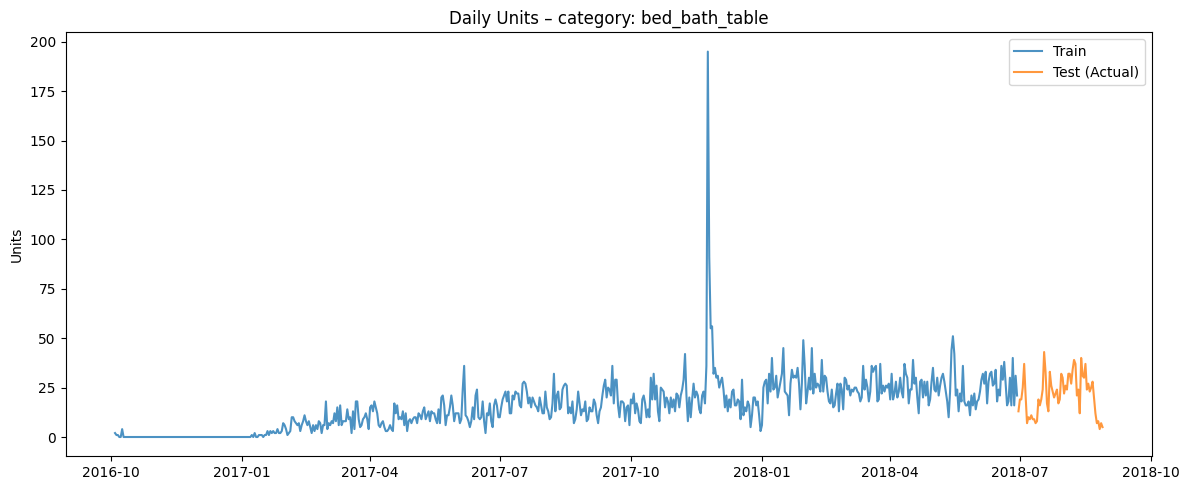

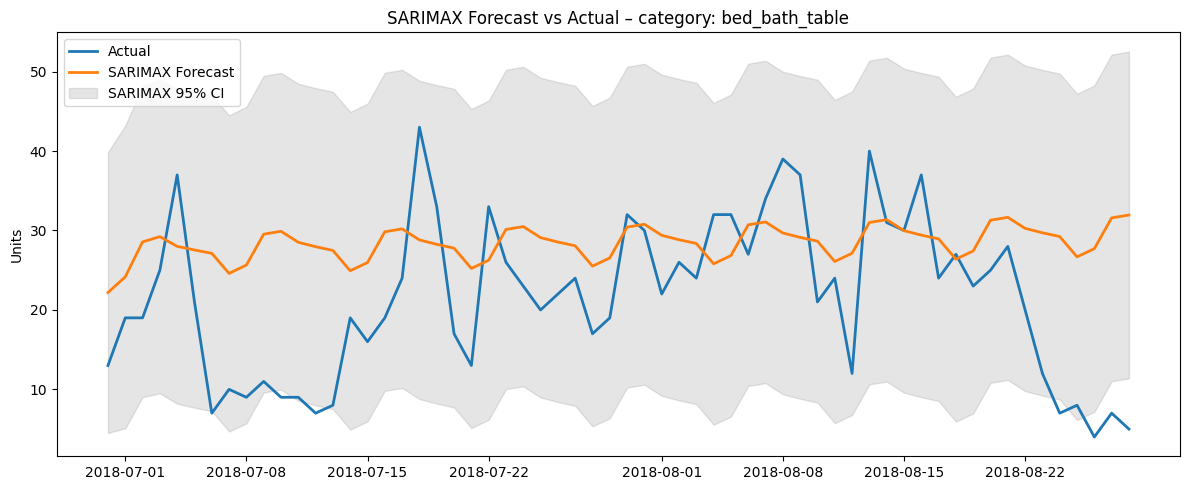

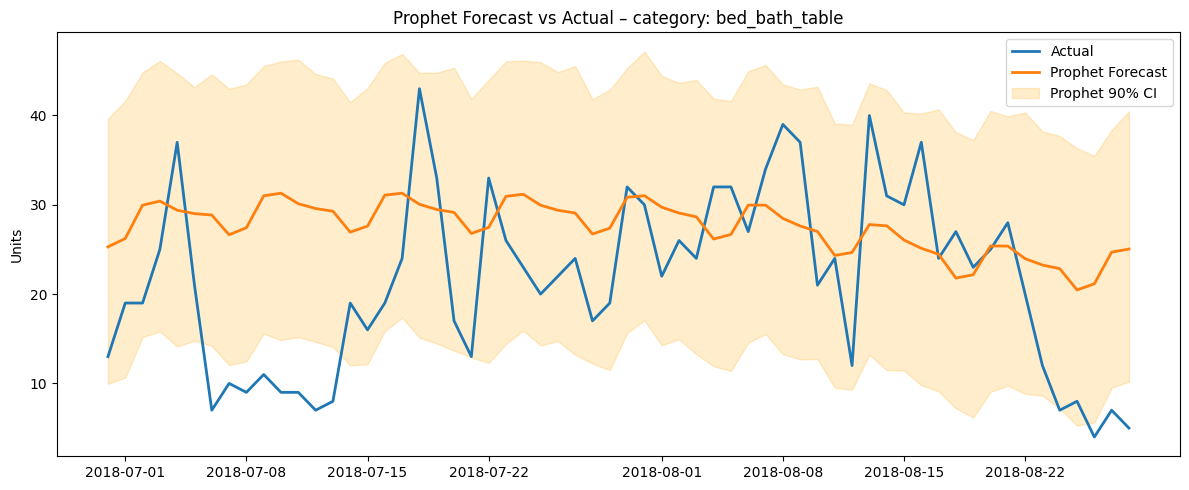


=== Inventory Policy (example) ===
Lead time (days): 7
Service level z:  1.65
Daily demand std (≈): 9.17
Expected lead-time demand (μ_LT): 168.2 units
Safety stock: 40.0 units
Reorder point (ROP = μ_LT + z·σ_LT): 208.3 units


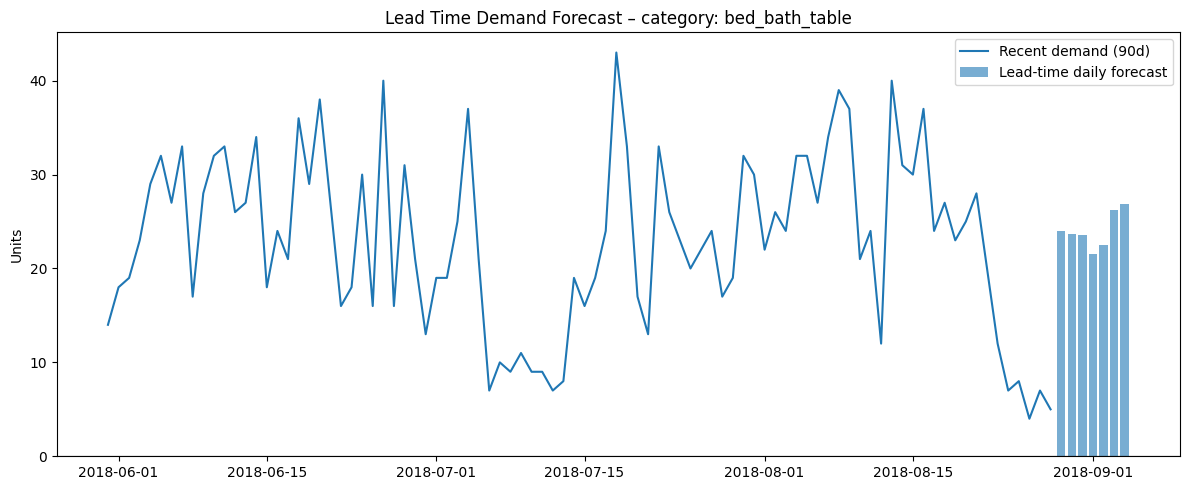

In [ ]:
# ============================================
# Inventory Forecasting (SARIMAX + Prophet)
# Olist dataset — Daily demand per category/product
# ============================================

# (Optional) first-time installs:
# !pip install --quiet pandas numpy matplotlib statsmodels prophet

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from itertools import product
from prophet import Prophet

# -----------------------------
# 0) Config: where are the CSVs?
# -----------------------------
DATA_DIR_CANDIDATES = [
    "/kaggle/input/brazilian-ecommerce",  # Kaggle
    "./brazilian-ecommerce",              # local copy
]

DATA_DIR = None
for p in DATA_DIR_CANDIDATES:
    if os.path.isdir(p):
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError("❌ Could not find Olist dataset folder. Set DATA_DIR to your path manually.")
print("Using DATA_DIR =", DATA_DIR)

# -----------------------------
# 1) Load Olist CSVs
# -----------------------------
orders   = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"))
items    = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(DATA_DIR, "olist_products_dataset.csv"))
transl   = pd.read_csv(os.path.join(DATA_DIR, "product_category_name_translation.csv"))

# -----------------------------
# 2) Minimal cleaning & joins
# -----------------------------
orders_use = orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]].copy()
orders_use["order_purchase_timestamp"] = pd.to_datetime(orders_use["order_purchase_timestamp"])

items_use = items[["order_id", "order_item_id", "product_id", "price", "freight_value"]].copy()
prod_use  = products[["product_id", "product_category_name"]].copy()

df = items_use.merge(prod_use, on="product_id", how="left")
df = df.merge(transl, on="product_category_name", how="left")
df = df.merge(orders_use, on="order_id", how="left")

# keep only demand-bearing orders
bad_status = {"canceled", "unavailable"}
df = df[~df["order_status"].isin(bad_status)].copy()

# demand date & quantity (one line = one unit)
df["date"] = pd.to_datetime(df["order_purchase_timestamp"].dt.date)
df["qty"] = 1.0

# -----------------------------
# 3) Aggregation level
# -----------------------------
# Choose "category" (default) OR "product"
AGG_LEVEL = "category"   # "category" or "product"

if AGG_LEVEL == "category":
    df["key"] = df["product_category_name_english"].fillna(df["product_category_name"]).fillna("Unknown")
elif AGG_LEVEL == "product":
    df["key"] = df["product_id"]
else:
    raise ValueError("AGG_LEVEL must be 'category' or 'product'.")

# -----------------------------
# 4) Pick a target series
# -----------------------------
topk = (
    df.groupby("key")["qty"].sum().sort_values(ascending=False).head(10)
)
print("Top keys by total units:\n", topk)

TARGET_KEY = topk.index[0]
print(f"\nTarget {AGG_LEVEL}: {TARGET_KEY}")

ts = (
    df[df["key"] == TARGET_KEY]
      .groupby("date")["qty"]
      .sum()
      .sort_index()
      .astype(float)
)

# complete daily index & fill zeros
full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq="D")
ts = ts.reindex(full_idx, fill_value=0.0)
ts.index.name = "date"

print(f"\nSeries length: {len(ts)} days; {ts.index.min().date()} → {ts.index.max().date()}")

# -----------------------------
# 5) Train / Test split
# -----------------------------
TEST_DAYS = 60
train = ts.iloc[:-TEST_DAYS]
test  = ts.iloc[-TEST_DAYS:]

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)")
print(f"Test : {test.index.min().date()} → {test.index.max().date()}  ({len(test)} days)")

# -----------------------------
# 6) SARIMAX auto-grid (AIC)
# -----------------------------
def sarima_auto_grid(
    y,
    seasonal_period=7,
    p_range=(0,2), d_range=(0,1), q_range=(0,2),
    P_range=(0,1), D_range=(0,1), Q_range=(0,1),
    enforce_stationarity=False, enforce_invertibility=False
):
    """
    Brute-force small SARIMA grid by AIC. Returns (best_result, order, seasonal_order).
    """
    best_aic = np.inf
    best_res, best_order, best_seasonal = None, None, None

    for p, d, q in product(range(p_range[0], p_range[1] + 1),
                           range(d_range[0], d_range[1] + 1),
                           range(q_range[0], q_range[1] + 1)):
        for P, D, Q in product(range(P_range[0], P_range[1] + 1),
                               range(D_range[0], D_range[1] + 1),
                               range(Q_range[0], Q_range[1] + 1)):
            order = (p, d, q)
            seasonal = (P, D, Q, seasonal_period)
            try:
                mod = sm.tsa.statespace.SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal,
                    trend="n",
                    enforce_stationarity=enforce_stationarity,
                    enforce_invertibility=enforce_invertibility
                )
                res = mod.fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res, best_order, best_seasonal = res, order, seasonal
            except Exception:
                continue
    return best_res, best_order, best_seasonal

best_res, best_order, best_seasonal = sarima_auto_grid(
    train,
    seasonal_period=7,        # weekly seasonality
    p_range=(0,2), d_range=(0,1), q_range=(0,2),
    P_range=(0,1), D_range=(0,1), Q_range=(0,1)
)

if best_res is None:
    raise RuntimeError("❌ No SARIMAX specification converged; widen grid or check the series.")

print("\nBest SARIMA order:", best_order, "Seasonal:", best_seasonal, "AIC:", round(best_res.aic, 2))

# Forecast with 95% CI over test window
n_fore = len(test)
sarimax_fc = best_res.get_forecast(steps=n_fore)
sarimax_mean = sarimax_fc.predicted_mean
sarimax_ci   = sarimax_fc.conf_int(alpha=0.05)
sarimax_mean.index = test.index
sarimax_ci.index   = test.index

# -----------------------------
# 7) Prophet model
# -----------------------------
prop_train = pd.DataFrame({"ds": train.index, "y": train.values})
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.90
)
prophet.fit(prop_train)

future = pd.DataFrame({"ds": test.index})
prop_fcst = prophet.predict(future)
prop_fcst = prop_fcst.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]]
prop_fcst.rename(columns={
    "yhat": "prophet_yhat",
    "yhat_lower": "prophet_lower",
    "yhat_upper": "prophet_upper"
}, inplace=True)

# -----------------------------
# 8) Metrics
# -----------------------------
def rmse(a, b):
    return float(np.sqrt(np.mean((np.array(a) - np.array(b))**2)))

def mae(a, b):
    return float(np.mean(np.abs(np.array(a) - np.array(b))))

def mape(a, b):
    a = np.array(a); b = np.array(b)
    mask = a != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((a[mask] - b[mask]) / a[mask])) * 100.0)

metrics = []
metrics.append({
    "Model": "SARIMAX",
    "RMSE": rmse(test, sarimax_mean),
    "MAE": mae(test, sarimax_mean),
    "MAPE%": mape(test, sarimax_mean)
})
metrics.append({
    "Model": "Prophet",
    "RMSE": rmse(test, prop_fcst["prophet_yhat"]),
    "MAE": mae(test, prop_fcst["prophet_yhat"]),
    "MAPE%": mape(test, prop_fcst["prophet_yhat"])
})
metrics_df = pd.DataFrame(metrics).set_index("Model").round(3)
print("\n=== Test Metrics ===\n", metrics_df)

# -----------------------------
# 9) Visualizations
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(train.index, train.values, label="Train", alpha=0.8)
plt.plot(test.index,  test.values,  label="Test (Actual)", alpha=0.8)
plt.title(f"Daily Units – {AGG_LEVEL}: {TARGET_KEY}")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

# SARIMAX plot
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Actual", lw=2)
plt.plot(test.index, sarimax_mean.values, label="SARIMAX Forecast", lw=2)
plt.fill_between(test.index, sarimax_ci.iloc[:,0], sarimax_ci.iloc[:,1],
                 color="gray", alpha=0.2, label="SARIMAX 95% CI")
plt.title(f"SARIMAX Forecast vs Actual – {AGG_LEVEL}: {TARGET_KEY}")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

# Prophet plot
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Actual", lw=2)
plt.plot(prop_fcst.index, prop_fcst["prophet_yhat"], label="Prophet Forecast", lw=2)
plt.fill_between(prop_fcst.index, prop_fcst["prophet_lower"], prop_fcst["prophet_upper"],
                 color="orange", alpha=0.2, label="Prophet 90% CI")
plt.title(f"Prophet Forecast vs Actual – {AGG_LEVEL}: {TARGET_KEY}")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Inventory policy (example)
# -----------------------------
LEAD_TIME_DAYS  = 7
SERVICE_LEVEL_Z = 1.65  # ~95% cycle service level

# In-sample residuals from Prophet for daily sigma
prop_insample = prophet.predict(pd.DataFrame({"ds": train.index}))
residuals = train.values - prop_insample["yhat"].values
sigma_d = np.std(residuals)  # daily demand std approx

# Forecast mean demand during lead time (next 7 days)
future_lt = pd.DataFrame({"ds": pd.date_range(test.index.max() + pd.Timedelta(days=1),
                                              periods=LEAD_TIME_DAYS, freq="D")})
fcst_lt = prophet.predict(future_lt)
mu_lt   = float(fcst_lt["yhat"].sum())
sigma_lt = float(sigma_d * np.sqrt(LEAD_TIME_DAYS))

safety_stock  = SERVICE_LEVEL_Z * sigma_lt
reorder_point = mu_lt + safety_stock

print("\n=== Inventory Policy (example) ===")
print(f"Lead time (days): {LEAD_TIME_DAYS}")
print(f"Service level z:  {SERVICE_LEVEL_Z}")
print(f"Daily demand std (≈): {sigma_d:.2f}")
print(f"Expected lead-time demand (μ_LT): {mu_lt:.1f} units")
print(f"Safety stock: {safety_stock:.1f} units")
print(f"Reorder point (ROP = μ_LT + z·σ_LT): {reorder_point:.1f} units")

# Visualize the lead-time forecast used for policy
plt.figure(figsize=(12,5))
plt.plot(ts.index[-90:], ts.values[-90:], label="Recent demand (90d)")
plt.bar(fcst_lt["ds"], fcst_lt["yhat"], alpha=0.6, label="Lead-time daily forecast")
plt.axhline(0, color="k", linewidth=0.8)
plt.title(f"Lead Time Demand Forecast – {AGG_LEVEL}: {TARGET_KEY}")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()


# Olist Recommendation Engine
# - Item–Item Collaborative Filtering (cosine on co-occurrence)
# - Matrix Factorization (TruncatedSVD)
# - Blended scoring + Propensity personalization (RFM heuristic)
# - Cold-start fallback + quick Recall@10 evaluation

Using DATA_DIR = /kaggle/input/brazilian-ecommerce
Train window: 2016-09-04 → 2018-07-05  (98992 rows)
Test  window: 2018-07-06 → 2018-09-03  (13109 rows)
Users in train: 83,745 | Items in train: 28,940

=== Recommendations for user 9343b198… (propensity-adjusted; p=0.38) ===
              customer_unique_id                       product_id        product_name    score
9343b1983b98b641123d716978deb844 44a34214a57dc373dcd80f54c919d006      sports_leisure 0.406906
9343b1983b98b641123d716978deb844 c4baedd846ed09b85f78a781b522f126        garden_tools 0.264953
9343b1983b98b641123d716978deb844 bb50f2e236e5eea0100680137654686c       health_beauty 0.241820
9343b1983b98b641123d716978deb844 c6336fa91fbd87c359e44f5dca5a90ed      sports_leisure 0.224181
9343b1983b98b641123d716978deb844 d3c044bd42d84a79e3b0c42662806a48      sports_leisure 0.166960
9343b1983b98b641123d716978deb844 06edb72f1e0c64b14c5b79353f7abea3      bed_bath_table 0.164726
9343b1983b98b641123d716978deb844 7ce94ab189134e2d3c05f496d

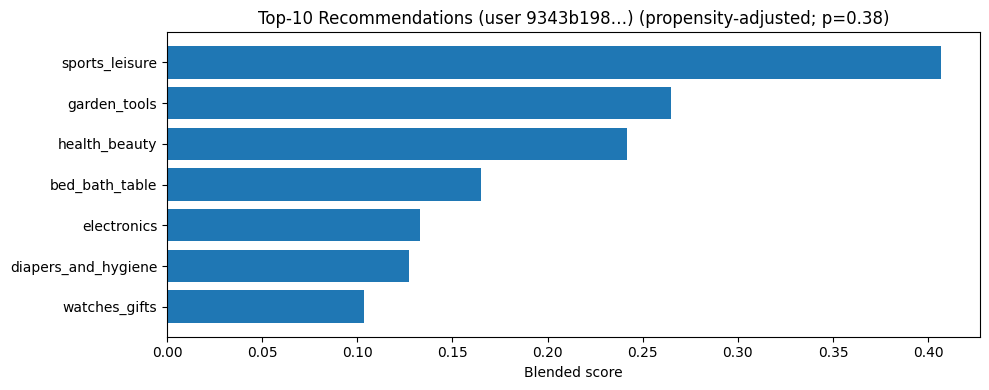


=== Recommendations for user 2fb691b5… (propensity-adjusted; p=0.53) ===
              customer_unique_id                       product_id          product_name    score
2fb691b537417b45297b69ac3bb59fe5 4c2394abfbac7ff59ec7a420918562fa         health_beauty 0.429238
2fb691b537417b45297b69ac3bb59fe5 2028bf1b01cafb2d2b1901fca4083222             perfumery 0.257195
2fb691b537417b45297b69ac3bb59fe5 a9516a079e37a9c9c36b9b78b10169e8      office_furniture 0.229753
2fb691b537417b45297b69ac3bb59fe5 461f43be3bdf8844e65b62d9ac2c7a5a         watches_gifts 0.215017
2fb691b537417b45297b69ac3bb59fe5 e0cf79767c5b016251fe139915c59a26         health_beauty 0.184419
2fb691b537417b45297b69ac3bb59fe5 601a360bd2a916ecef0e88de72a6531a            cool_stuff 0.181953
2fb691b537417b45297b69ac3bb59fe5 54d7ad85b648d3cb2b7069ed446d7f35 computers_accessories 0.154731
2fb691b537417b45297b69ac3bb59fe5 7a10781637204d8d10485c71a6108a2e         watches_gifts 0.126461
2fb691b537417b45297b69ac3bb59fe5 dbb67791e405873b259e

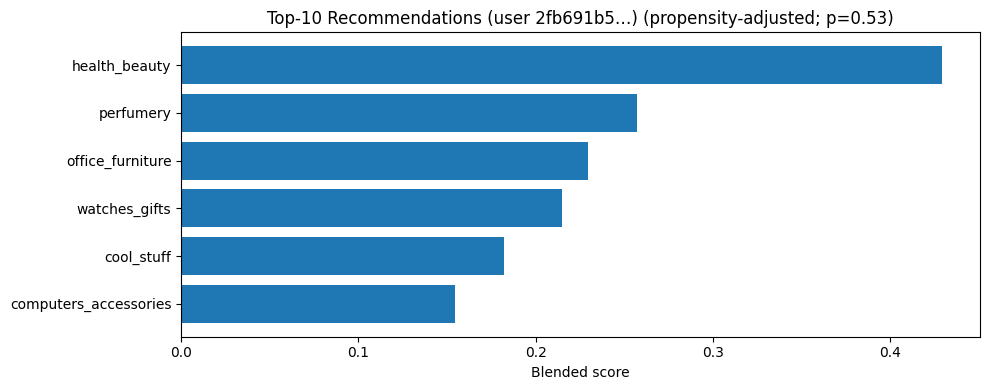


=== Recommendations for user 0181f57a… (propensity-adjusted; p=0.22) ===
              customer_unique_id                       product_id    product_name    score
0181f57a87c6a2f0e0fe2807f67aef0e 7a10781637204d8d10485c71a6108a2e   watches_gifts 0.383363
0181f57a87c6a2f0e0fe2807f67aef0e 362b773250263786dd58670d2df42c3b  sports_leisure 0.276231
0181f57a87c6a2f0e0fe2807f67aef0e d2085f7e0f9533605386960fc7e987ec    garden_tools 0.266545
0181f57a87c6a2f0e0fe2807f67aef0e 6cdd53843498f92890544667809f1595   health_beauty 0.255245
0181f57a87c6a2f0e0fe2807f67aef0e a19b6951c75da43aad691622dd2f6abe furniture_decor 0.206332
0181f57a87c6a2f0e0fe2807f67aef0e d493f5a208254fe85b3ab55d898461a1            food 0.156817
0181f57a87c6a2f0e0fe2807f67aef0e 54d9ac713e253fa1fae9c8003b011c2a      cool_stuff 0.152651
0181f57a87c6a2f0e0fe2807f67aef0e bb50f2e236e5eea0100680137654686c   health_beauty 0.148847
0181f57a87c6a2f0e0fe2807f67aef0e 84f456958365164420cfc80fbe4c7fab  bed_bath_table 0.120850
0181f57a87c6a2f0

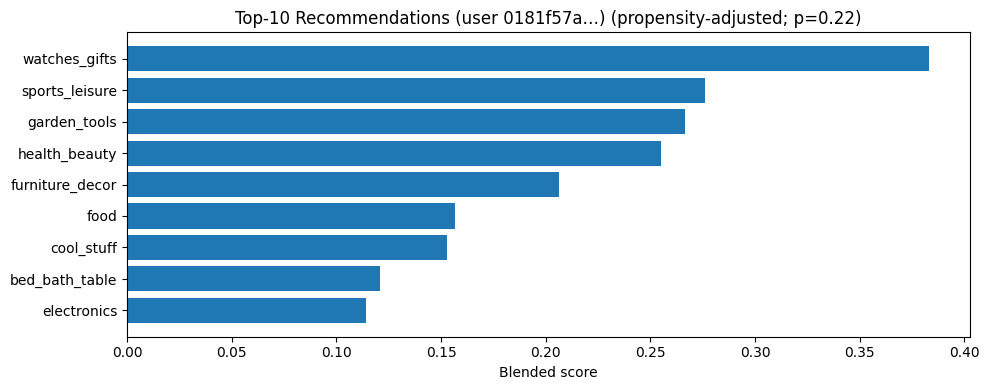


=== Recommendations for user ebedac08… (propensity-adjusted; p=0.57) ===
              customer_unique_id                       product_id     product_name    score
ebedac088806fe85e8083426d9e952e3 a5341e3f8155dbb3e62323d3ea289729  furniture_decor 0.435466
ebedac088806fe85e8083426d9e952e3 f6eda47c88d786adf6f3e3f016833927         pet_shop 0.416653
ebedac088806fe85e8083426d9e952e3 c857b96593773e940454e76efa8eabb3  furniture_decor 0.228252
ebedac088806fe85e8083426d9e952e3 28b4eced95a52d9c437a4caf9d311b95  furniture_decor 0.218667
ebedac088806fe85e8083426d9e952e3 7fb7c9580222a2af9eb7a95a6ce85fc5       housewares 0.210889
ebedac088806fe85e8083426d9e952e3 f4f4debbcfcafe6858d1e37a1f6e436e office_furniture 0.210601
ebedac088806fe85e8083426d9e952e3 ec16be6dfd2b67c4f576d7c7ccda1358     garden_tools 0.207483
ebedac088806fe85e8083426d9e952e3 a3430558283765c5dd94dd0381acc9c2   sports_leisure 0.206926
ebedac088806fe85e8083426d9e952e3 d493f5a208254fe85b3ab55d898461a1             food 0.001726
ebedac

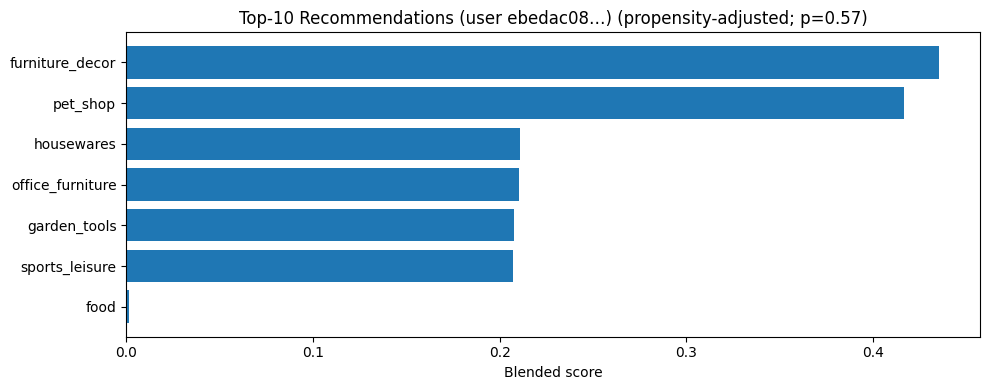


=== Recommendations for user db3073c0… (propensity-adjusted; p=0.54) ===
              customer_unique_id                       product_id        product_name    score
db3073c0e926f86ee0683c94d12f5ff6 2028bf1b01cafb2d2b1901fca4083222           perfumery 0.431659
db3073c0e926f86ee0683c94d12f5ff6 44a34214a57dc373dcd80f54c919d006      sports_leisure 0.390672
db3073c0e926f86ee0683c94d12f5ff6 0bcc3eeca39e1064258aa1e932269894        garden_tools 0.380396
db3073c0e926f86ee0683c94d12f5ff6 a19b6951c75da43aad691622dd2f6abe     furniture_decor 0.265089
db3073c0e926f86ee0683c94d12f5ff6 3fdb534dccf5bc9ab0406944b913787d diapers_and_hygiene 0.239390
db3073c0e926f86ee0683c94d12f5ff6 08574b074924071f4e201e151b152b4e        garden_tools 0.231392
db3073c0e926f86ee0683c94d12f5ff6 7a10781637204d8d10485c71a6108a2e       watches_gifts 0.176360
db3073c0e926f86ee0683c94d12f5ff6 04c4a4b9c924494fcf82e0fba966f955       watches_gifts 0.125442
db3073c0e926f86ee0683c94d12f5ff6 b5e13c9a353102f79c6206ff5cb61a50      

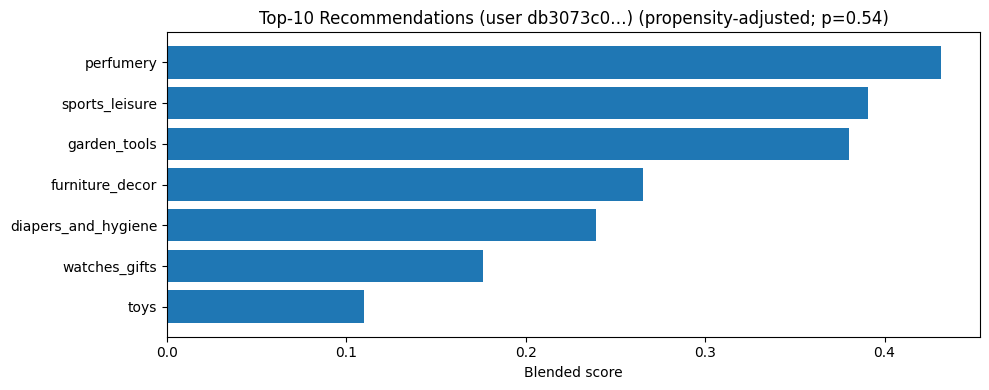


Quick Recall@10 on seen test users: 0.011


In [ ]:


import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict
from datetime import timedelta

import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

# (Optional) If you want to try loading your LSTM later:
try:
    import tensorflow as tf
except Exception:
    tf = None

# -----------------------------
# 0) Config: dataset location
# -----------------------------
DATA_DIR_CANDIDATES = [
    "/kaggle/input/brazilian-ecommerce",   # Kaggle
    "./brazilian-ecommerce",               # local copy
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if os.path.isdir(p)), None)
if DATA_DIR is None:
    raise FileNotFoundError("❌ Could not find Olist dataset folder. Set DATA_DIR to the directory holding CSVs.")
print("Using DATA_DIR =", DATA_DIR)

# -----------------------------
# 1) Load Olist CSVs
# -----------------------------
customers = pd.read_csv(os.path.join(DATA_DIR, "olist_customers_dataset.csv"))
orders    = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"))
items     = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "olist_products_dataset.csv"))
transl    = pd.read_csv(os.path.join(DATA_DIR, "product_category_name_translation.csv"))

# Minimal cleaning
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders_use = orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]].copy()

cust_use = customers[["customer_id", "customer_unique_id"]].copy()
items_use = items[["order_id", "product_id", "price"]].copy()

prod_use = products[["product_id", "product_category_name"]].copy()
prod_use = prod_use.merge(transl, on="product_category_name", how="left")

# Join to get user (customer_unique_id) on each item event
df = (items_use
      .merge(orders_use, on="order_id", how="left")
      .merge(cust_use, on="customer_id", how="left")
      .merge(prod_use, on="product_id", how="left"))

# Filter to realized demand (exclude canceled/unavailable)
bad_status = {"canceled", "unavailable"}
df = df[~df["order_status"].isin(bad_status)].copy()

df["user_id"] = df["customer_unique_id"]
df["item_id"] = df["product_id"]
df["date"]    = pd.to_datetime(df["order_purchase_timestamp"].dt.date)
df["qty"]     = 1.0  # implicit feedback

# -----------------------------
# 2) Chronological train/test split
# -----------------------------
HOLDOUT_DAYS = 60
max_day = df["date"].max()
cut_day = max_day - pd.Timedelta(days=HOLDOUT_DAYS)

train_df = df[df["date"] <= cut_day].copy()
test_df  = df[df["date"]  > cut_day].copy()

print(f"Train window: {train_df['date'].min().date()} → {train_df['date'].max().date()}  ({len(train_df)} rows)")
print(f"Test  window: {test_df['date'].min().date()} → {test_df['date'].max().date()}  ({len(test_df)} rows)")

# Keep only users/items present in train (evaluation for seen users)
train_users = set(train_df["user_id"])
train_items = set(train_df["item_id"])
test_df_in  = test_df[test_df["user_id"].isin(train_users)].copy()

# -----------------------------
# 3) Build sparse user–item matrix
# -----------------------------
ui_counts = (train_df.groupby(["user_id","item_id"], as_index=False)["qty"].sum())
ui_counts["val"] = ui_counts["qty"]  # could use log1p(qty) as well

user2idx = {u:i for i,u in enumerate(ui_counts["user_id"].unique())}
item2idx = {p:i for i,p in enumerate(ui_counts["item_id"].unique())}
idx2user = {i:u for u,i in user2idx.items()}
idx2item = {i:p for p,i in item2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)
print(f"Users in train: {n_users:,} | Items in train: {n_items:,}")

ui_counts = ui_counts[ui_counts["user_id"].isin(user2idx) & ui_counts["item_id"].isin(item2idx)]
rows = ui_counts["user_id"].map(user2idx).values
cols = ui_counts["item_id"].map(item2idx).values
vals = ui_counts["val"].astype(float).values

X_train = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items))

# Popular items (for cold-start users)
pop_items = (train_df.groupby("item_id")["qty"].sum().sort_values(ascending=False))
popular_item_ids = [iid for iid in pop_items.index if iid in item2idx][:200]

# Map item -> readable name
prod_meta = prod_use.copy()
prod_meta["name"] = prod_meta["product_category_name_english"].fillna(prod_meta["product_category_name"]).fillna("Unknown")
prod_name = dict(zip(prod_meta["product_id"], prod_meta["name"]))

# -----------------------------
# 4) Item–Item Collaborative Filtering (cosine)
#     (Corrected: no .A1, safe division, top-K pruning)
# -----------------------------
Xt = X_train.T.tocsr()
C = (Xt @ X_train).tocsr()      # item–item co-occurrence
C.setdiag(0)                    # remove self counts
C.eliminate_zeros()

diag = np.sqrt(np.asarray(C.diagonal()).ravel() + 1e-12)  # norms (1D array)
TOPK_SIM = 50

item_neighbors = {}  # item_idx -> list[(neighbor_idx, sim)]
for i in range(n_items):
    row = C.getrow(i)
    if row.nnz == 0 or diag[i] <= 0:
        item_neighbors[i] = []
        continue

    js = row.indices
    vs = row.data
    denom = diag[i] * diag[js]
    mask = denom > 1e-12
    if not np.any(mask):
        item_neighbors[i] = []
        continue

    js = js[mask]
    sims = vs[mask] / denom[mask]

    # top-K neighbors
    if js.size > TOPK_SIM:
        top_idx = np.argpartition(-sims, TOPK_SIM)[:TOPK_SIM]
        js = js[top_idx]
        sims = sims[top_idx]

    order = np.argsort(-sims)
    item_neighbors[i] = [(int(j), float(sims[k])) for k, j in enumerate(js[order])]

def recommend_cf_for_user(u_idx, seen_set=None, topn=10):
    """Score candidates by summing item–item similarities to user’s seen items."""
    if seen_set is None:
        seen_set = set()
    start, end = X_train.indptr[u_idx], X_train.indptr[u_idx+1]
    user_items = X_train.indices[start:end]
    scores = defaultdict(float)
    for it in user_items:
        for j, sim in item_neighbors.get(it, []):
            if j in seen_set:
                continue
            scores[j] += sim
    if not scores:
        return []
    pairs = sorted(scores.items(), key=lambda x: -x[1])[:topn]
    return pairs  # [(item_idx, score)]

# -----------------------------
# 5) Matrix Factorization (TruncatedSVD)
# -----------------------------
K = 64
svd = TruncatedSVD(n_components=K, random_state=42)
user_factors = svd.fit_transform(X_train)   # (n_users, K)
item_factors = svd.components_.T            # (n_items, K)

def recommend_mf_for_user(u_idx, seen_set=None, topn=10):
    if seen_set is None:
        seen_set = set()
    uf = user_factors[u_idx]               # (K,)
    scores = item_factors @ uf             # (n_items,)
    if seen_set:
        idx_seen = np.fromiter(seen_set, dtype=int, count=len(seen_set))
        scores[idx_seen] = -np.inf
    top_idx = np.argpartition(-scores, min(topn, len(scores)-1))[:topn]
    top_idx = top_idx[np.argsort(-scores[top_idx])]
    return [(int(j), float(scores[j])) for j in top_idx]

# -----------------------------
# 6) Propensity (predictive) integration (RFM heuristic here)
# -----------------------------
# Recency/Frequency in train → propensity in [0,1]
recency_last = (train_df.groupby("user_id")["date"].max()
                .reindex(list(user2idx.keys())))
freq = (train_df.groupby("user_id")["qty"].sum()
        .reindex(list(user2idx.keys())))

recency_days = (cut_day - recency_last).dt.days
recency_days = recency_days.replace([np.inf, np.nan], recency_days.dropna().max()).fillna(30)
freq = freq.fillna(0.0)

rec_norm = 1.0 - (recency_days - recency_days.min()) / (recency_days.max() - recency_days.min() + 1e-9)
freq_norm = (freq - freq.min()) / (freq.max() - freq.min() + 1e-9)
heuristic_propensity = (0.6 * rec_norm + 0.4 * freq_norm).fillna(0.5)

def get_user_propensity(u_id):
    # If you have a trained LSTM + feature pipeline, compute its prob here.
    # For now, use heuristic RFM-based propensity:
    return float(heuristic_propensity.get(u_id, 0.5))

# -----------------------------
# 7) Blend & Recommend API
# -----------------------------
def recommend_for_customer(customer_unique_id, topn=10, w_cf=0.5, w_mf=0.5, apply_propensity=True):
    """
    Recommend Top-N items for a user by blending CF and MF scores,
    with optional propensity scaling.
    """
    # Cold-start: unseen user → popular items
    if customer_unique_id not in user2idx:
        recs = [(item2idx[iid], 1.0) for iid in popular_item_ids[:topn] if iid in item2idx]
        return format_recs(recs, customer_unique_id, note="(cold-start: popular items)")

    u_idx = user2idx[customer_unique_id]
    # Seen set
    start, end = X_train.indptr[u_idx], X_train.indptr[u_idx+1]
    seen = set(X_train.indices[start:end])

    # CF/MF candidates
    cf_pairs = recommend_cf_for_user(u_idx, seen_set=seen, topn=200)
    mf_pairs = recommend_mf_for_user(u_idx, seen_set=seen, topn=200)
    cf_scores = dict(cf_pairs)
    mf_scores = dict(mf_pairs)

    cand_idxs = set(cf_scores.keys()) | set(mf_scores.keys())
    if not cand_idxs:
        # fallback popular (excluding seen)
        fallback = [iid for iid in popular_item_ids if iid in item2idx and item2idx[iid] not in seen]
        recs = [(item2idx[iid], 1.0) for iid in fallback[:topn]]
        return format_recs(recs, customer_unique_id, note="(fallback: popular items)")

    # Normalize each score dict to [0,1]
    def norm_scores(d):
        if not d:
            return {}
        v = np.fromiter(d.values(), dtype=float)
        lo, hi = v.min(), v.max()
        if hi <= lo + 1e-12:
            return {k: 0.0 for k in d}
        return {k: (d[k] - lo) / (hi - lo) for k in d}

    cf_n = norm_scores(cf_scores)
    mf_n = norm_scores(mf_scores)

    # Blend
    blended = {}
    for j in cand_idxs:
        blended[j] = w_cf * cf_n.get(j, 0.0) + w_mf * mf_n.get(j, 0.0)

    # Propensity personalization
    note = ""
    if apply_propensity:
        p_user = get_user_propensity(customer_unique_id)  # [0,1]
        gamma = 0.3  # personalization strength
        scale = (1 - gamma + gamma * p_user)
        for j in blended:
            blended[j] *= scale
        note = f"(propensity-adjusted; p={p_user:.2f})"

    # Top-N
    top = sorted(blended.items(), key=lambda x: -x[1])[:topn]
    return format_recs(top, customer_unique_id, note=note)

def format_recs(pairs, customer_unique_id, note=""):
    """Convert (item_idx, score) → human-readable DataFrame."""
    rows = []
    for j, s in pairs:
        pid = idx2item[j]
        name = prod_name.get(pid, "Unknown")
        rows.append({
            "customer_unique_id": customer_unique_id,
            "product_id": pid,
            "product_name": name,
            "score": float(s)
        })
    return pd.DataFrame(rows), note

# -----------------------------
# 8) Demo on a few users + plot
# -----------------------------
example_users = list(train_users)[:5]
for cu in example_users:
    recs, note = recommend_for_customer(cu, topn=10, w_cf=0.5, w_mf=0.5, apply_propensity=True)
    print(f"\n=== Recommendations for user {cu[:8]}… {note} ===")
    print(recs.head(10).to_string(index=False))

    plt.figure(figsize=(10,4))
    plt.barh(recs["product_name"].head(10), recs["score"].head(10))
    plt.gca().invert_yaxis()
    plt.title(f"Top-10 Recommendations (user {cu[:8]}…) {note}")
    plt.xlabel("Blended score")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 9) Quick offline eval: Recall@K
# -----------------------------
def recall_at_k(test_df_in, K=10):
    # Ground-truth next-period purchases per user
    gt = (test_df_in.groupby("user_id")["item_id"]
          .apply(lambda s: set(s.values)))
    users_eval = [u for u in gt.index if u in user2idx]
    if not users_eval:
        return np.nan

    recalls = []
    for u in users_eval:
        recs, _ = recommend_for_customer(u, topn=K, w_cf=0.5, w_mf=0.5, apply_propensity=True)
        rec_set = set(recs["product_id"].values)
        true_set = gt.loc[u]
        if len(true_set) == 0:
            continue
        hit = len(rec_set & true_set)
        denom = min(K, len(true_set))
        recalls.append(hit / denom if denom > 0 else 0.0)

    return float(np.mean(recalls)) if recalls else np.nan

r10 = recall_at_k(test_df_in, K=10)
print(f"\nQuick Recall@10 on seen test users: {r10:.3f}")


# SHAP Explainability — Olist Customer Behaviour Classification
# Model: RandomForest (tree-based, fast for SHAP TreeExplainer)

Using DATA_DIR = /kaggle/input/brazilian-ecommerce
Final dataset shape: (99224, 19)
Class balance: {1: 0.7707, 0: 0.2293}

=== Test Report (RF) ===
              precision    recall  f1-score   support

           0     0.7890    0.3098    0.4449      4551
           1     0.8261    0.9753    0.8945     15294

    accuracy                         0.8227     19845
   macro avg     0.8075    0.6426    0.6697     19845
weighted avg     0.8176    0.8227    0.7914     19845


[INFO] Computing permutation importance…

Top 15 features by Permutation Importance:
delivered_vs_estimated_days    0.0550
order_status_delivered         0.0271
purchase_to_delivered_days     0.0029
order_status_shipped           0.0009
order_status_canceled          0.0008
order_status_processing        0.0003
category_mode_baby             0.0002
order_status_invoiced          0.0001
category_mode_Unknown          0.0001
category_mode_health_beauty    0.0001
category_mode_auto             0.0001
customer_state_CE    

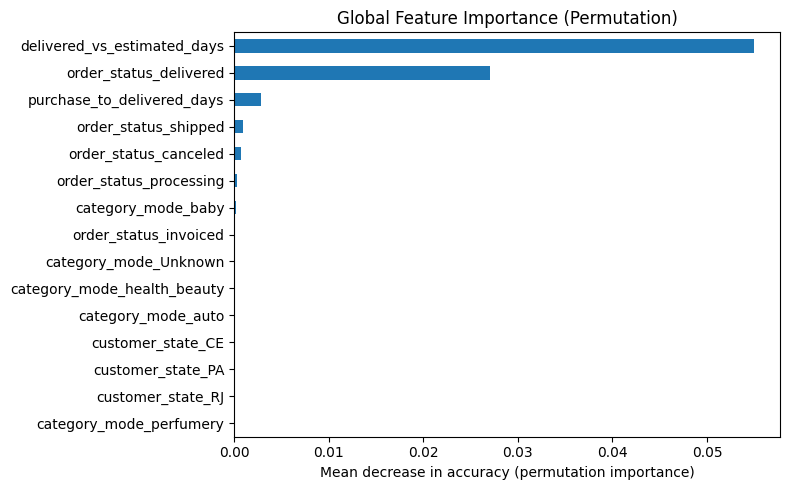


[INFO] Trying PDP for up to 5 top features: ['delivered_vs_estimated_days', 'order_status_delivered', 'purchase_to_delivered_days', 'order_status_shipped', 'order_status_canceled']


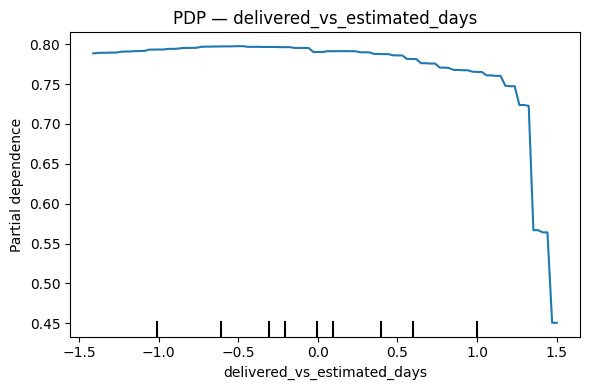

[SKIP] PDP for 'order_status_delivered' failed: cannot reshape array of size 1 into shape (2)


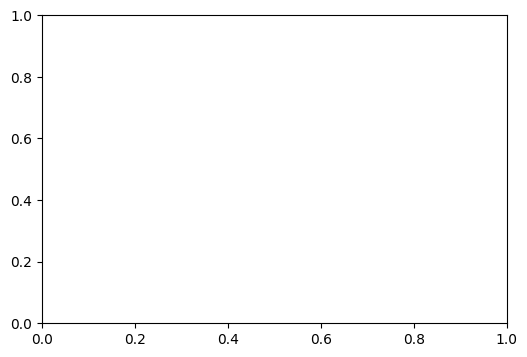

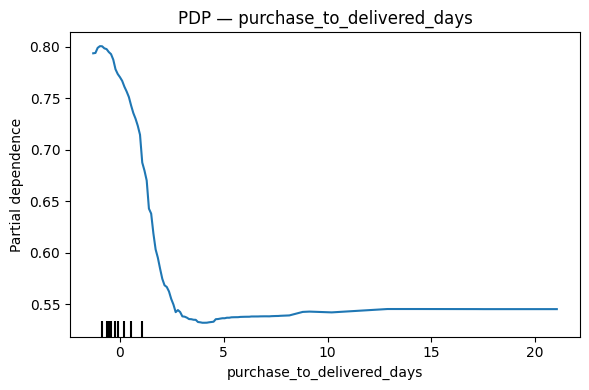

[SKIP] PDP for 'order_status_shipped' failed: cannot reshape array of size 1 into shape (2)
[SKIP] PDP for 'order_status_canceled' failed: cannot reshape array of size 1 into shape (2)

[DONE] Fast explainability with robust PDP.


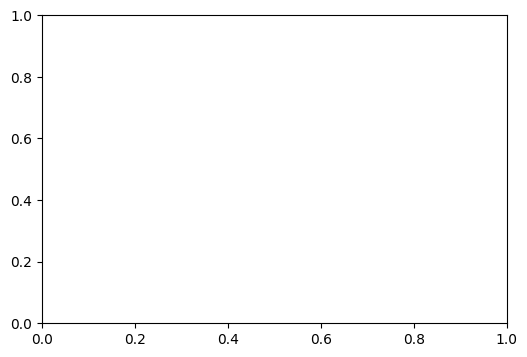

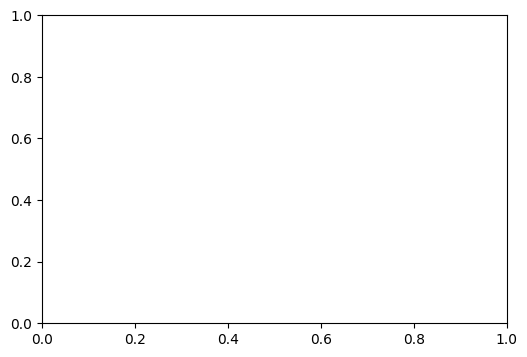

In [ ]:
# ================================================================
# Fast Explainability for Olist (Fixed PDP: skip constant features)
# ================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# -----------------------------
# Config (speed knobs)
# -----------------------------
DATA_DIR       = "/kaggle/input/brazilian-ecommerce"   # change if needed
RANDOM_SEED    = 42
N_TREES        = 80
PI_N_REPEATS   = 5
TOP_K_PDP_TRY  = 5   # we’ll try up to 5 top features and skip constants

print(f"Using DATA_DIR = {DATA_DIR}")

# -----------------------------
# 1) Load only needed columns
# -----------------------------
orders = pd.read_csv(
    os.path.join(DATA_DIR, "olist_orders_dataset.csv"),
    usecols=[
        "order_id","customer_id","order_status",
        "order_purchase_timestamp","order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)
order_items = pd.read_csv(
    os.path.join(DATA_DIR, "olist_order_items_dataset.csv"),
    usecols=["order_id","order_item_id","product_id","price","freight_value"]
)
payments = pd.read_csv(
    os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"),
    usecols=["order_id","payment_type","payment_installments","payment_value"]
)
reviews = pd.read_csv(
    os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"),
    usecols=["order_id","review_score","review_creation_date"]
)
products = pd.read_csv(
    os.path.join(DATA_DIR, "olist_products_dataset.csv"),
    usecols=[
        "product_id","product_category_name",
        "product_weight_g","product_length_cm","product_height_cm",
        "product_width_cm","product_name_lenght",
        "product_description_lenght","product_photos_qty"
    ]
)
customers = pd.read_csv(
    os.path.join(DATA_DIR, "olist_customers_dataset.csv"),
    usecols=["customer_id","customer_state"]
)
trans = pd.read_csv(
    os.path.join(DATA_DIR, "product_category_name_translation.csv"),
    usecols=["product_category_name","product_category_name_english"]
)

# -----------------------------
# 2) Minimal cleaning & merges
# -----------------------------
for col in ["order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")

products = products.merge(trans, how="left", on="product_category_name")

enriched_items = order_items.merge(
    products[[
        "product_id","product_category_name_english",
        "product_weight_g","product_length_cm","product_height_cm",
        "product_width_cm","product_name_lenght",
        "product_description_lenght","product_photos_qty"
    ]],
    on="product_id", how="left"
)

item_agg = enriched_items.groupby("order_id").agg(
    item_count=("order_item_id","max"),
    price_sum=("price","sum"),
    freight_sum=("freight_value","sum"),
    prod_weight_mean=("product_weight_g","mean"),
    prod_len_mean=("product_length_cm","mean"),
    prod_height_mean=("product_height_cm","mean"),
    prod_width_mean=("product_width_cm","mean"),
    name_len_mean=("product_name_lenght","mean"),
    desc_len_mean=("product_description_lenght","mean"),
    photos_qty_mean=("product_photos_qty","mean"),
    category_mode=("product_category_name_english",
                   lambda s: s.value_counts(dropna=True).idxmax() if s.notna().any() else "Unknown")
).reset_index()

pay_agg = payments.groupby("order_id").agg(
    payment_value_sum=("payment_value","sum"),
    payment_installments_max=("payment_installments","max"),
    payment_type_mode=("payment_type",
                       lambda s: s.value_counts(dropna=True).idxmax() if s.notna().any() else "not_defined")
).reset_index()

df = (orders
      .merge(item_agg, on="order_id", how="left")
      .merge(pay_agg, on="order_id", how="left")
      .merge(customers, on="customer_id", how="left")
      .merge(reviews[["order_id","review_score"]], on="order_id", how="left"))

# -----------------------------
# 3) Target & features
# -----------------------------
df = df[df["review_score"].notna()].copy()
df["target"] = (df["review_score"] >= 4).astype(int)

df["purchase_to_delivered_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days
df["delivered_vs_estimated_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

num_cols = [
    "item_count","price_sum","freight_sum",
    "prod_weight_mean","prod_len_mean","prod_height_mean","prod_width_mean",
    "name_len_mean","desc_len_mean","photos_qty_mean",
    "payment_value_sum","payment_installments_max",
    "purchase_to_delivered_days","delivered_vs_estimated_days"
]
cat_cols = ["category_mode","payment_type_mode","customer_state","order_status"]

keep_cols = ["target"] + num_cols + cat_cols
df = df[keep_cols].copy()

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))
for c in cat_cols:
    df[c] = df[c].fillna("Unknown").astype(str)

print("Final dataset shape:", df.shape)
print("Class balance:", df["target"].value_counts(normalize=True).round(4).to_dict())

# -----------------------------
# 4) Split & preprocess
# -----------------------------
X = df.drop(columns=["target"])
y = df["target"].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop"
)

X_train = preprocess.fit_transform(X_train_raw)
X_test  = preprocess.transform(X_test_raw)

feature_names = preprocess.get_feature_names_out()
feature_names = [n.split("__", 1)[1] if "__" in n else n for n in feature_names]

# -----------------------------
# 5) Fast RandomForest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=N_TREES,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf.fit(X_train, y_train)

print("\n=== Test Report (RF) ===")
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

# -----------------------------
# 6) Permutation Importance (fast)
# -----------------------------
print("\n[INFO] Computing permutation importance…")
pi = permutation_importance(
    rf, X_test, y_test,
    n_repeats=PI_N_REPEATS,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
pi_mean = pd.Series(pi.importances_mean, index=feature_names).sort_values(ascending=False)
print("\nTop 15 features by Permutation Importance:")
print(pi_mean.head(15).round(4))

plt.figure(figsize=(8, 5))
pi_mean.head(15).iloc[::-1].plot(kind="barh")
plt.xlabel("Mean decrease in accuracy (permutation importance)")
plt.title("Global Feature Importance (Permutation)")
plt.tight_layout()
plt.show()

# -----------------------------
# 7) PDP with safety: skip constant features
# -----------------------------
def plot_pdp_safe(model, X, feat_name, feat_index, feature_names):
    """Plot PDP only if the feature has >=2 unique values in X."""
    col_vals = X[:, feat_index]
    if np.unique(col_vals).size < 2:
        print(f"[SKIP] PDP for '{feat_name}' — constant in X_test.")
        return False
    try:
        fig, ax = plt.subplots(figsize=(6,4))
        PartialDependenceDisplay.from_estimator(
            model, X, [feat_index], feature_names=feature_names, ax=ax
        )
        ax.set_title(f"PDP — {feat_name}")
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"[SKIP] PDP for '{feat_name}' failed: {e}")
        return False

top_try = list(pi_mean.head(TOP_K_PDP_TRY).index)
print(f"\n[INFO] Trying PDP for up to {TOP_K_PDP_TRY} top features: {top_try}")
plotted = 0
for feat in top_try:
    idx = feature_names.index(feat)
    if plot_pdp_safe(rf, X_test, feat, idx, feature_names):
        plotted += 1

if plotted == 0:
    print("[INFO] No PDP plotted (all top features constant in X_test). Try increasing TOP_K_PDP_TRY or using train data to pick features.")

print("\n[DONE] Fast explainability with robust PDP.")


 99%|===================| 1590/1600 [02:38<00:00]       

<Figure size 640x480 with 0 Axes>

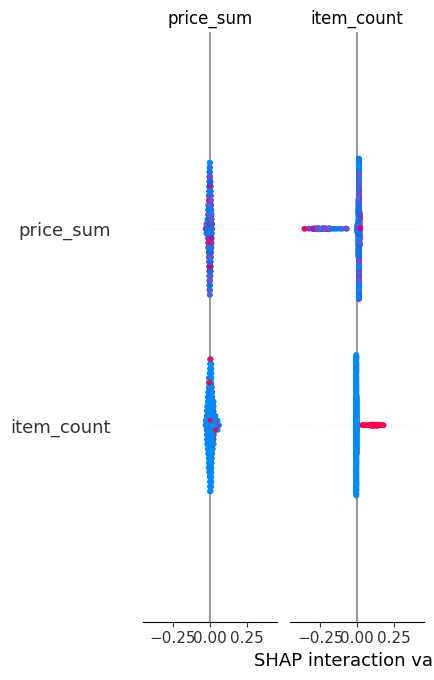

<Figure size 640x480 with 0 Axes>

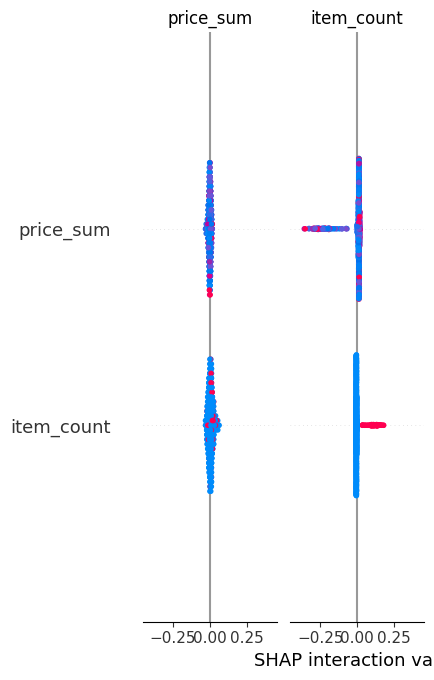

TypeError: only length-1 arrays can be converted to Python scalars

In [7]:
# ============================
# SHAP Explainability (Corrected)
# ============================
import shap
import matplotlib.pyplot as plt
import numpy as np

# Choose which trained model to explain:
model = rf   # or dt, or xgb_model

# Background + test subsets for SHAP (fast execution)
BGN_SAMPLES   = 1000
TEST_SAMPLES  = 800
RNG           = np.random.RandomState(42)

bg_idx   = RNG.choice(X_train.shape[0], size=min(BGN_SAMPLES, X_train.shape[0]), replace=False)
test_idx = RNG.choice(X_test.shape[0],  size=min(TEST_SAMPLES, X_test.shape[0]), replace=False)
X_bg     = X_train[bg_idx]
X_shap   = X_test[test_idx]

# Build fast TreeExplainer
explainer = shap.TreeExplainer(model, data=X_bg, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_shap, check_additivity=False)

# If classifier, take the positive class SHAP values
is_list = isinstance(shap_values, list)
SV = shap_values[1] if is_list else shap_values

# 1) Global importance (bar + beeswarm)
plt.figure()
shap.summary_plot(SV, X_shap, feature_names=feature_names, plot_type="bar", show=True)

plt.figure()
shap.summary_plot(SV, X_shap, feature_names=feature_names, plot_type="violin", show=True)

# 2) Dependence plot on top feature
mean_abs = np.abs(SV).mean(axis=0)
top_idx = int(np.argsort(mean_abs)[-1])
top_feat = feature_names[top_idx]
print(f"[SHAP] Top feature: {top_feat}")

plt.figure()
shap.dependence_plot(top_feat, SV, X_shap, feature_names=feature_names, show=True)

# 3) Local explanation for a single row
row = 0
try:
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value[1] if is_list else explainer.expected_value,
        SV[row],
        feature_names=feature_names,
        max_display=15
    )
except Exception as e:
    print(f"[SHAP] Waterfall skipped: {e}")

print("[SHAP] Done.")
